<a href="https://colab.research.google.com/github/dragonhumeante07/pruebas-de-codigos/blob/main/ejercicio_3_taller4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Taller 3 caso 4**
* **Introduccion**:
En este trabajo se abordará el caso 4 del taller 3 el cual consite en crear un sitema que permita:


1.   Buscar productos por código
2.   Buscar por nombre
3.   Analizar descripciones para encontrar productos relacionados

Para ello se deben aplicar tres tipos de búsqueda:
1. Búsqueda Binaria: para buscar productos por código
2. Búsqueda Secuencial: para buscar productos por nombre
3. Búsqueda de Texto: para buscar productos por descripciones relacionadas


#**Cargar desde el drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Busqueda binaria**


In [ ]:
import csv

class Producto:
    def __init__(self, codigo, nombre, descripcion, precio):
        self.codigo = codigo
        self.nombre = nombre
        self.descripcion = descripcion
        self.precio = precio
        self.contador_busquedas = 0

    def __str__(self):
        return f"Producto: {self.nombre} Código: {self.codigo} - Descripción: {self.descripcion}- precio: {self.precio}"

    def productos_mas_buscados(self):
        return self.contador_busquedas

def busqueda_binaria(lista, valor):
    inicio = 0
    final = len(lista) - 1

    while inicio <= final:
        media = (inicio + final) // 2

        if lista[media].codigo == valor:
            lista[media].contador_busquedas += 1
            return media
        elif lista[media].codigo > valor:
            final = media - 1
        else:
            inicio = media + 1

    return None

catalogo = []
ruta_permanente = '/content/drive/MyDrive/catalogo.txt'

# 1. Try-Except al leer el archivo (por si hay datos corruptos)
try:
    with open(ruta_permanente, mode='r', encoding='utf-8') as archivo:
        lector = csv.reader(archivo)
        for lista in lector:
            if len(lista) == 4:
                codigo, nombre, descripcion, precio = lista
                try:
                    producto = Producto(int(codigo), nombre, descripcion, int(precio))
                    catalogo.append(producto)
                except ValueError:
                    print(f"Error: Omitiendo línea debido a datos numéricos inválidos: {lista}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {ruta_permanente}")


while True:
    try:
        buscado = int(input("Ingrese el codigo del producto que desea buscar: "))
    except ValueError:
        print("Entrada inválida. Por favor, ingrese un número entero (solo dígitos).")
        continue  # Regresa al inicio del bucle sin ejecutar la búsqueda

    resultado = busqueda_binaria(catalogo, buscado)
    if len(resultado) > 0:
        print(catalogo[resultado])
    else:
        print("No se encontró el producto.")

    respuesta = input("¿Desea buscar otro producto? (s/n): ")
    if respuesta.lower() == 'n':
        break

# Reporte de los más buscados (se mantiene igual)
productos_buscado = [x for x in catalogo if x.contador_busquedas > 0]
mas_buscado = 0
for i in range(len(productos_buscado)):
    if productos_buscado[i].contador_busquedas > mas_buscado:
        mas_buscado = productos_buscado[i].contador_busquedas

productos_mas_buscados = [x for x in productos_buscado if x.contador_busquedas == mas_buscado]

print("\nLos productos más buscados son:")
for productos in productos_mas_buscados:
    print(productos)

Ingrese el codigo del producto que desea buscar: 1
Producto: Smartphone Código: 1 - Descripción: Tecnología- precio: 120000
¿Desea buscar otro producto? (s/n): n

Los productos más buscados son:
Producto: Smartphone Código: 1 - Descripción: Tecnología- precio: 120000


#**Grafico de tiempo(Binaria)**

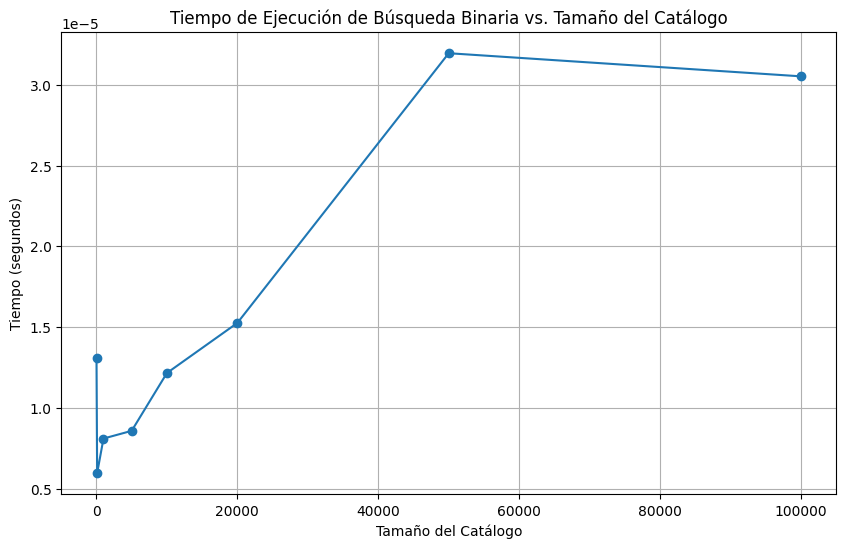

In [ ]:
import time
import matplotlib.pyplot as plt
import random

# Redefine Producto class and busqueda_binaria function for self-containment
class Producto:
    def __init__(self,codigo,nombre,descripcion,precio):
        self.codigo = codigo
        self.nombre = nombre
        self.descripcion = descripcion
        self.precio = precio
        self.contador_busquedas = 0
    def __str__(self):
        return f"Producto: {self.nombre} Código: {self.codigo} - Descripción: {self.descripcion}- precio: {self.precio}"
    def productos_mas_buscados(self):
        return self.contador_busquedas

def busqueda_binaria(lista,valor,inicio,final):
    if inicio > final:
        return None
    media = (inicio + final)//2
    if lista[media].codigo == valor:
        lista[media].contador_busquedas += 1
        return media
    elif lista[media].codigo > valor:
        return busqueda_binaria(lista,valor,inicio,media - 1)
    else :
        return busqueda_binaria(lista,valor,media + 1,final)

# Function to create a dummy catalog for testing
def crear_catalogo_dummy(size):
    dummy_catalogo = []
    for i in range(size):
        # Ensure unique and sorted codes for binary search
        codigo = i + 1
        nombre = f"Producto{codigo}"
        descripcion = "Descripcion de prueba"
        precio = random.randint(100, 1000)
        dummy_catalogo.append(Producto(codigo, nombre, descripcion, precio))
    return dummy_catalogo

sizes = [10, 100, 1000, 5000, 10000, 20000, 50000, 100000]
times = []

for size in sizes:
    catalogo_test = crear_catalogo_dummy(size)

    # Pick a random code to search for within the catalog
    # Or, if you want to test worst-case, search for a non-existent code
    search_value = random.randint(1, size)

    start_time = time.time()
    busqueda_binaria(catalogo_test, search_value, 0, len(catalogo_test) - 1)
    end_time = time.time()
    times.append(end_time - start_time)

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o')
plt.title('Tiempo de Ejecución de Búsqueda Binaria vs. Tamaño del Catálogo')
plt.xlabel('Tamaño del Catálogo')
plt.ylabel('Tiempo (segundos)')
plt.grid(True)
# Removed plt.xscale('log')
# Removed plt.yscale('log')
plt.show()

#**Busqueda lineal**

In [ ]:
import csv
class Producto:
    def __init__(self,codigo,nombre,descripcion,precio):
        self.codigo = codigo
        self.nombre = nombre
        self.descripcion = descripcion
        self.precio = precio
        self.contador_busquedas = 0
    def __str__(self):
        return f"Producto: {self.nombre} Código: {self.codigo} - Descripción: {self.descripcion}- precio: {self.precio}"

def buscar_producto(lista,valor):
    for producto in lista:
        if producto.nombre.lower() == valor.lower():
            producto.contador_busquedas += 1
            return producto
    return None

catalogo = []
ruta_permanente = '/content/drive/MyDrive/catalogo.txt'
with open(ruta_permanente, mode = 'r',encoding='utf-8') as archivo:
    lector = csv.reader(archivo)
    for lista in lector:
        if len(lista) == 4:
            codigo, nombre, descripcion, precio = lista
            producto = Producto(int(codigo), nombre, descripcion, int(precio))
            catalogo.append(producto)

while True:
    buscado = input  ("Ingrese el nombre del producto que desea buscar: ")
    resultado = buscar_producto(catalogo,buscado)
    if resultado is not None:
        print(resultado)
    else:
        print("No se encontró el producto.")
    respuesta = input("¿Desea buscar otro producto? (s/n): ")
    if respuesta.lower() == 'n':
        break

productos_buscado = [x for x in catalogo if x.contador_busquedas > 0]
mas_buscado = 0
for i in range(len(productos_buscado)):
    if productos_buscado[i].contador_busquedas > mas_buscado:
        mas_buscado = productos_buscado[i].contador_busquedas
productos_mas_buscados = [x for x in productos_buscado if x.contador_busquedas == mas_buscado]
print("Los productos más buscados son:")
for productos in productos_mas_buscados:
    print(productos)


Ingrese el nombre del producto que desea buscar: 1
No se encontró el producto.
¿Desea buscar otro producto? (s/n): hola
Ingrese el nombre del producto que desea buscar: hola
No se encontró el producto.
¿Desea buscar otro producto? (s/n): #
Ingrese el nombre del producto que desea buscar: #
No se encontró el producto.
¿Desea buscar otro producto? (s/n): n
Los productos más buscados son:


#**Grafico de tiempo(lineal)**

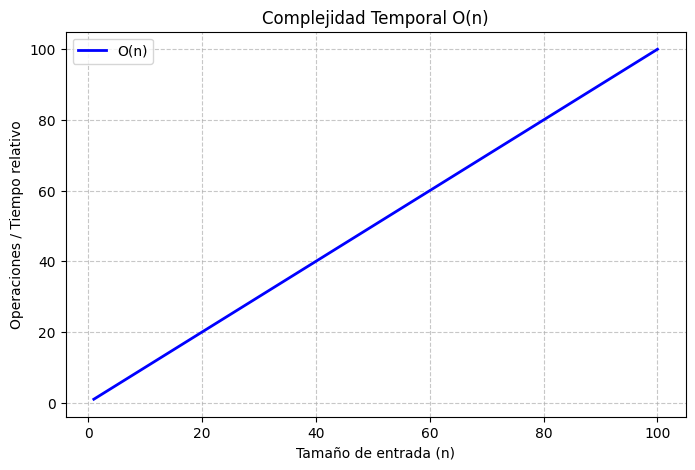

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Tamaños de entrada
n = np.arange(1, 101)

# Complejidad O(n)
tiempo = n

plt.figure(figsize=(8, 5))
plt.plot(n, tiempo, label='O(n)', color='blue', linewidth=2)

plt.title('Complejidad Temporal O(n)')
plt.xlabel('Tamaño de entrada (n)')
plt.ylabel('Operaciones / Tiempo relativo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()

#**Busqueda texto**

In [ ]:

import csv
class Producto:
    def __init__(self,codigo,nombre,descripcion,precio):
        self.codigo = codigo
        self.nombre = nombre
        self.descripcion = descripcion
        self.precio = precio
        self.contador_busquedas = 0
    def __str__(self):
        return f"Producto: {self.nombre} Código: {self.codigo} - Descripción: {self.descripcion}- precio: {self.precio}"


def busqueda_texto(lista,patron):
  posiciones = []
  for bucasdo in lista:
      texto = bucasdo.descripcion.lower()
      for i in range(len(texto)-len(patron)+1):
          if texto[i:i+len(patron)] == patron.lower():
              posiciones.append(bucasdo)

              bucasdo.contador_busquedas += 1

  return posiciones

catalogo = []
ruta_permanente = '/content/drive/MyDrive/catalogo.txt'
with open(ruta_permanente, mode = 'r',encoding='utf-8') as archivo:
    lector = csv.reader(archivo)
    for lista in lector:
        if len(lista) == 4:
            codigo, nombre, descripcion, precio = lista
            producto = Producto(int(codigo), nombre, descripcion, int(precio))
            catalogo.append(producto)

while True:
    buscado = input("Ingrese la descripcion del producto: ")
    resultado = busqueda_texto(catalogo,buscado)
    if len(resultado) > 0:
        for productos in resultado:
          print(productos)
    else:
        print("No se encontró el producto.")

    respuesta = input("¿Desea buscar otro producto? (s/n): ")
    if respuesta.lower() == 'n':
        break

productos_buscado = [x for x in catalogo if x.contador_busquedas > 0]
mas_buscado = 0
for i in range(len(productos_buscado)):
    if productos_buscado[i].contador_busquedas > mas_buscado:
        mas_buscado = productos_buscado[i].contador_busquedas
productos_mas_buscados = [x for x in productos_buscado if x.contador_busquedas == mas_buscado]
print("Los productos más buscados son:")
for productos in productos_mas_buscados:
    print(productos)

Ingrese la descripcion del producto: cuidado personal
Producto: Crema hidratante Código: 7 - Descripción: Cuidado Personal- precio: 1400
Producto: Champú sólido Código: 8 - Descripción: Cuidado Personal- precio: 5700
Producto: Protector Solar FPS 50 Código: 18 - Descripción: Cuidado Personal- precio: 12000
Producto: Pasta de dente natural Código: 19 - Descripción: Cuidado Personal- precio: 3200
Producto: Jabón de Avena Código: 20 - Descripción: Cuidado Personal- precio: 1800
Producto: Bálsamo Labial Código: 24 - Descripción: Cuidado Personal- precio: 2500
Producto: Sérum Facial Código: 28 - Descripción: Cuidado Personal- precio: 16500
Producto: Acondicionador Vegano Código: 32 - Descripción: Cuidado Personal- precio: 5900
Producto: Gel de Ducha Código: 36 - Descripción: Cuidado Personal- precio: 4500
Producto: Desodorante Natural Código: 40 - Descripción: Cuidado Personal- precio: 3800
Producto: Mascarilla Capilar Código: 44 - Descripción: Cuidado Personal- precio: 7200
Producto: Exfol

#**Grafico de tiempo(texto)**

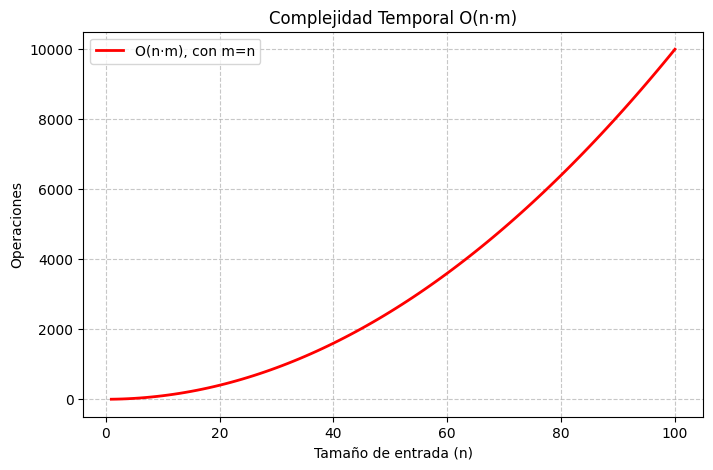

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Tamaños de entrada
n = np.arange(1, 101)

# Complejidad O(n*m) suponiendo m = n
operaciones = n * n

plt.figure(figsize=(8, 5))
plt.plot(n, operaciones, color='red', linewidth=2, label='O(n·m), con m=n')

plt.title('Complejidad Temporal O(n·m)')
plt.xlabel('Tamaño de entrada (n)')
plt.ylabel('Operaciones')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()

#Complejidad:
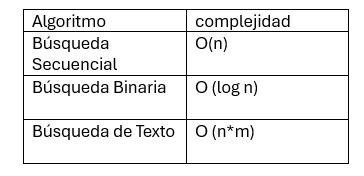

